<a href="https://colab.research.google.com/github/JuTluszcz/Productivity/blob/main/NucleosRegionaisDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CÉLULA 1: Importações e Google Drive
# ==========================================
import warnings
warnings.filterwarnings('ignore')

# Instalação de pacotes necessários
!pip install optuna shap openpyxl -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
import tensorflow.keras.backend as K

import shap
from google.colab import drive, files

# Fixar sementes para reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

# Montar Google Drive
try:
    drive.mount('/content/drive')
    print("✅ Google Drive montado com sucesso!")
except Exception as e:
    print(f"🚨 Erro ao montar o Google Drive: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.1 MB/s eta 0:00:00
Mounted at /content/drive
✅ Google Drive montado com sucesso!


In [ ]:
# ==========================================
# CÉLULA 2: Carregamento e Detrending
# ==========================================
caminho_csv = "/content/drive/MyDrive/MESTRADO/Embrapa/parciais/MarchacomAgs_Final.csv"
df = pd.read_csv(caminho_csv)

# Limpeza e padronização do nome do Núcleo Regional
df['NUCLEO REGIONAL'] = df['NUCLEO REGIONAL'].astype(str).str.strip()

# Criar a coluna alvo 'Produtividade_kg_ha'
df['Produtividade_kg_ha'] = (df['PRODUCAO (t)'] * 1000) / df['AREA TOTAL (ha)']

# Tratar infinitos e nulos
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['Produtividade_kg_ha'], inplace=True)

# Extrair o ano da safra
df['ano_safra'] = df['SAFRA'].str.split('/').str[1].astype(int) + 2000

print("Iniciando cálculo de Detrending por município...")

TARGET_ORIGINAL = 'Produtividade_kg_ha'
TARGET_ANOMALIA = 'Produtividade_Anomalia'
ANO_CORTE_TREINO = 2022

lista_municipios = df['Município'].unique()
df_list = []

for municipio in lista_municipios:
    df_city = df[df['Município'] == municipio].sort_values('ano_safra').copy()
    df_city_train = df_city[df_city['ano_safra'] <= ANO_CORTE_TREINO]

    if len(df_city_train) < 2:
        df_city[TARGET_ANOMALIA] = 0
        df_list.append(df_city)
        continue

    X_trend_train = df_city_train[['ano_safra']]
    y_trend_train = df_city_train[TARGET_ORIGINAL]

    trend_model = LinearRegression()
    trend_model.fit(X_trend_train, y_trend_train)

    produtividade_esperada = trend_model.predict(df_city[['ano_safra']])
    df_city[TARGET_ANOMALIA] = df_city[TARGET_ORIGINAL] - produtividade_esperada
    df_list.append(df_city)

df_detrended = pd.concat(df_list).sort_values(by=['geocodigo_ibge', 'ano_safra']).reset_index(drop=True)
print(f"✅ Detrending concluído! Coluna '{TARGET_ANOMALIA}' criada.")

Iniciando cálculo de Detrending por município...
✅ Detrending concluído! Coluna 'Produtividade_Anomalia' criada.


In [ ]:
# ==========================================
# CÉLULA 3: Filtro Fenológico de Features
# ==========================================
cols_to_drop = [
    'Produtividade_kg_ha', 'ano_safra', 'SAFRA',
    'PRODUCAO (t)', 'AREA TOTAL (ha)', TARGET_ANOMALIA,
    'Município', 'geocodigo_ibge', 'REGIAO', 'NUCLEO REGIONAL', 'CULTURA',
    'Plantio_25%', 'Plantio_50%', 'Plantio_75%',
    'Colheita_25%', 'Colheita_50%', 'Colheita_75%',
    'run', 'trtc', 'labelc', 'sowingy', 'sowingday',
    'prod_agregada_regional (t)', 'biomass_grainf', 'Produtividade_Anomalia_Lag1'
]

FEATURES_temp = [c for c in df_detrended.columns if c not in cols_to_drop]

# Filtro fenológico: remover estágios 1, 2 e 5 (foco em floração/stg3 e enchimento/stg4)
fases_para_remover = ['_stg1', '_stg2', '_stg5']
FEATURES_focadas = [col for col in FEATURES_temp if not any(fase in col for fase in fases_para_remover)]

FEATURES = df_detrended[FEATURES_focadas].select_dtypes(include=[np.number]).columns.tolist()

print(f"Features originais: {len(FEATURES_temp)}")
print(f"Features selecionadas após filtro fenológico: {len(FEATURES)}")

Features originais: 65
Features selecionadas após filtro fenológico: 47


In [ ]:
# ==========================================
# CÉLULA 4: Funções de Modelagem e Plottagem
# ==========================================
def calcular_metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    amplitude = y_real.max() - y_real.min()
    nrmse = rmse / amplitude if amplitude != 0 else 0

    return {
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'NRMSE': round(nrmse, 4),
        'R2': round(r2, 4)
    }

def criar_modelo_dl(input_dim):
    K.clear_session()
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim, kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        BatchNormalization(),
        Dropout(0.15),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, clipvalue=1.0), loss=Huber(delta=1.0))
    return model

In [ ]:
# ==========================================
# CÉLULA 1: Treinamento e Armazenamento por Núcleo
# ==========================================
import shap
import pandas as pd
import numpy as np

# Dicionário para armazenar os resultados e dados de cada núcleo
dados_graficos = {}
resultados_lista = []

nucleos = df_detrended['NUCLEO REGIONAL'].unique()
print(f"Iniciando processamento de {len(nucleos)} Núcleos Regionais...\n")

for idx, nucleo in enumerate(nucleos, 1):
    df_nucleo = df_detrended[df_detrended['NUCLEO REGIONAL'] == nucleo].sort_values('ano_safra')

    mask_train = df_nucleo['ano_safra'] <= ANO_CORTE_TREINO
    mask_test = df_nucleo['ano_safra'] > ANO_CORTE_TREINO

    df_train, df_test = df_nucleo[mask_train], df_nucleo[mask_test]

    if len(df_train) < 5 or len(df_test) < 1:
        continue

    X_train, y_train = df_train[FEATURES], df_train[TARGET_ANOMALIA]
    X_test, y_test = df_test[FEATURES], df_test[TARGET_ANOMALIA]

    # Pré-processamento
    imputer = SimpleImputer(strategy='mean')
    X_tr_clean = imputer.fit_transform(X_train)
    X_te_clean = imputer.transform(X_test)

    scaler_x = StandardScaler()
    X_tr_scaled = scaler_x.fit_transform(X_tr_clean)
    X_te_scaled = scaler_x.transform(X_te_clean)

    scaler_y = StandardScaler()
    y_tr_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    # Pesos de amostra para eventos extremos
    desvio_medio = np.abs(y_train).mean()
    pesos_treino = 1.0 + (np.abs(y_train) / (desvio_medio + 1e-5)) * 2.0

    # Treino do Modelo
    model = criar_modelo_dl(X_tr_scaled.shape[1])
    early_stop = EarlyStopping(monitor='loss', patience=25, restore_best_weights=True)

    model.fit(
        X_tr_scaled, y_tr_scaled,
        sample_weight=pesos_treino.values,
        epochs=180,
        batch_size=min(32, len(X_tr_scaled)),
        callbacks=[early_stop],
        verbose=0
    )

    # Previsões desnormalizadas
    y_pred_tr = scaler_y.inverse_transform(model.predict(X_tr_scaled, verbose=0)).flatten()
    y_pred_te = scaler_y.inverse_transform(model.predict(X_te_scaled, verbose=0)).flatten()

    # --- CORREÇÃO DO SHAP ---
    # Envelopamos o model.predict para retornar vetor 1D (.ravel()) e desnormalizar na escala real
    def predict_shap(x):
        preds_scaled = model.predict(x, verbose=0)
        return scaler_y.inverse_transform(preds_scaled).ravel()

    # Amostra de background e teste
    bg_samples = X_tr_scaled[np.random.choice(X_tr_scaled.shape[0], min(25, len(X_tr_scaled)), replace=False)]
    test_samples = X_te_scaled[:min(40, len(X_te_scaled))]

    explainer = shap.KernelExplainer(predict_shap, bg_samples)
    shap_vals = explainer.shap_values(test_samples, l1_reg="num_features(8)")

    # Salvar tudo no dicionário
    dados_graficos[nucleo] = {
        'y_tr_real': y_train, 'y_tr_pred': y_pred_tr,
        'y_te_real': y_test, 'y_te_pred': y_pred_te,
        'df_train': df_train, 'df_test': df_test,
        'shap_vals': shap_vals,
        'test_samples_df': pd.DataFrame(test_samples, columns=FEATURES)
    }

    # Métricas
    m_tr = calcular_metricas(y_train, y_pred_tr)
    m_te = calcular_metricas(y_test, y_pred_te)
    resultados_lista.append({
        'NUCLEO REGIONAL': nucleo,
        'R2_Treino': m_tr['R2'], 'MAE_Treino': m_tr['MAE'], 'NRMSE_Treino': m_tr['NRMSE'],
        'R2_Teste': m_te['R2'], 'MAE_Teste': m_te['MAE'], 'NRMSE_Teste': m_te['NRMSE']
    })

    print(f"✅ Processado: {nucleo}")

print("\nProcessamento concluído para todos os núcleos!")

Iniciando processamento de 20 Núcleos Regionais...



  0%|          | 0/32 [00:00<?, ?it/s]

✅ Processado: Cornélio Procópio


  0%|          | 0/16 [00:00<?, ?it/s]

✅ Processado: Umuarama


...

✅ Processado: Guarapuava


  0%|          | 0/14 [00:00<?, ?it/s]

✅ Processado: Laranjeiras do Sul


  0%|          | 0/14 [00:00<?, ?it/s]

✅ Processado: Irati

Processamento concluído para todos os núcleos!


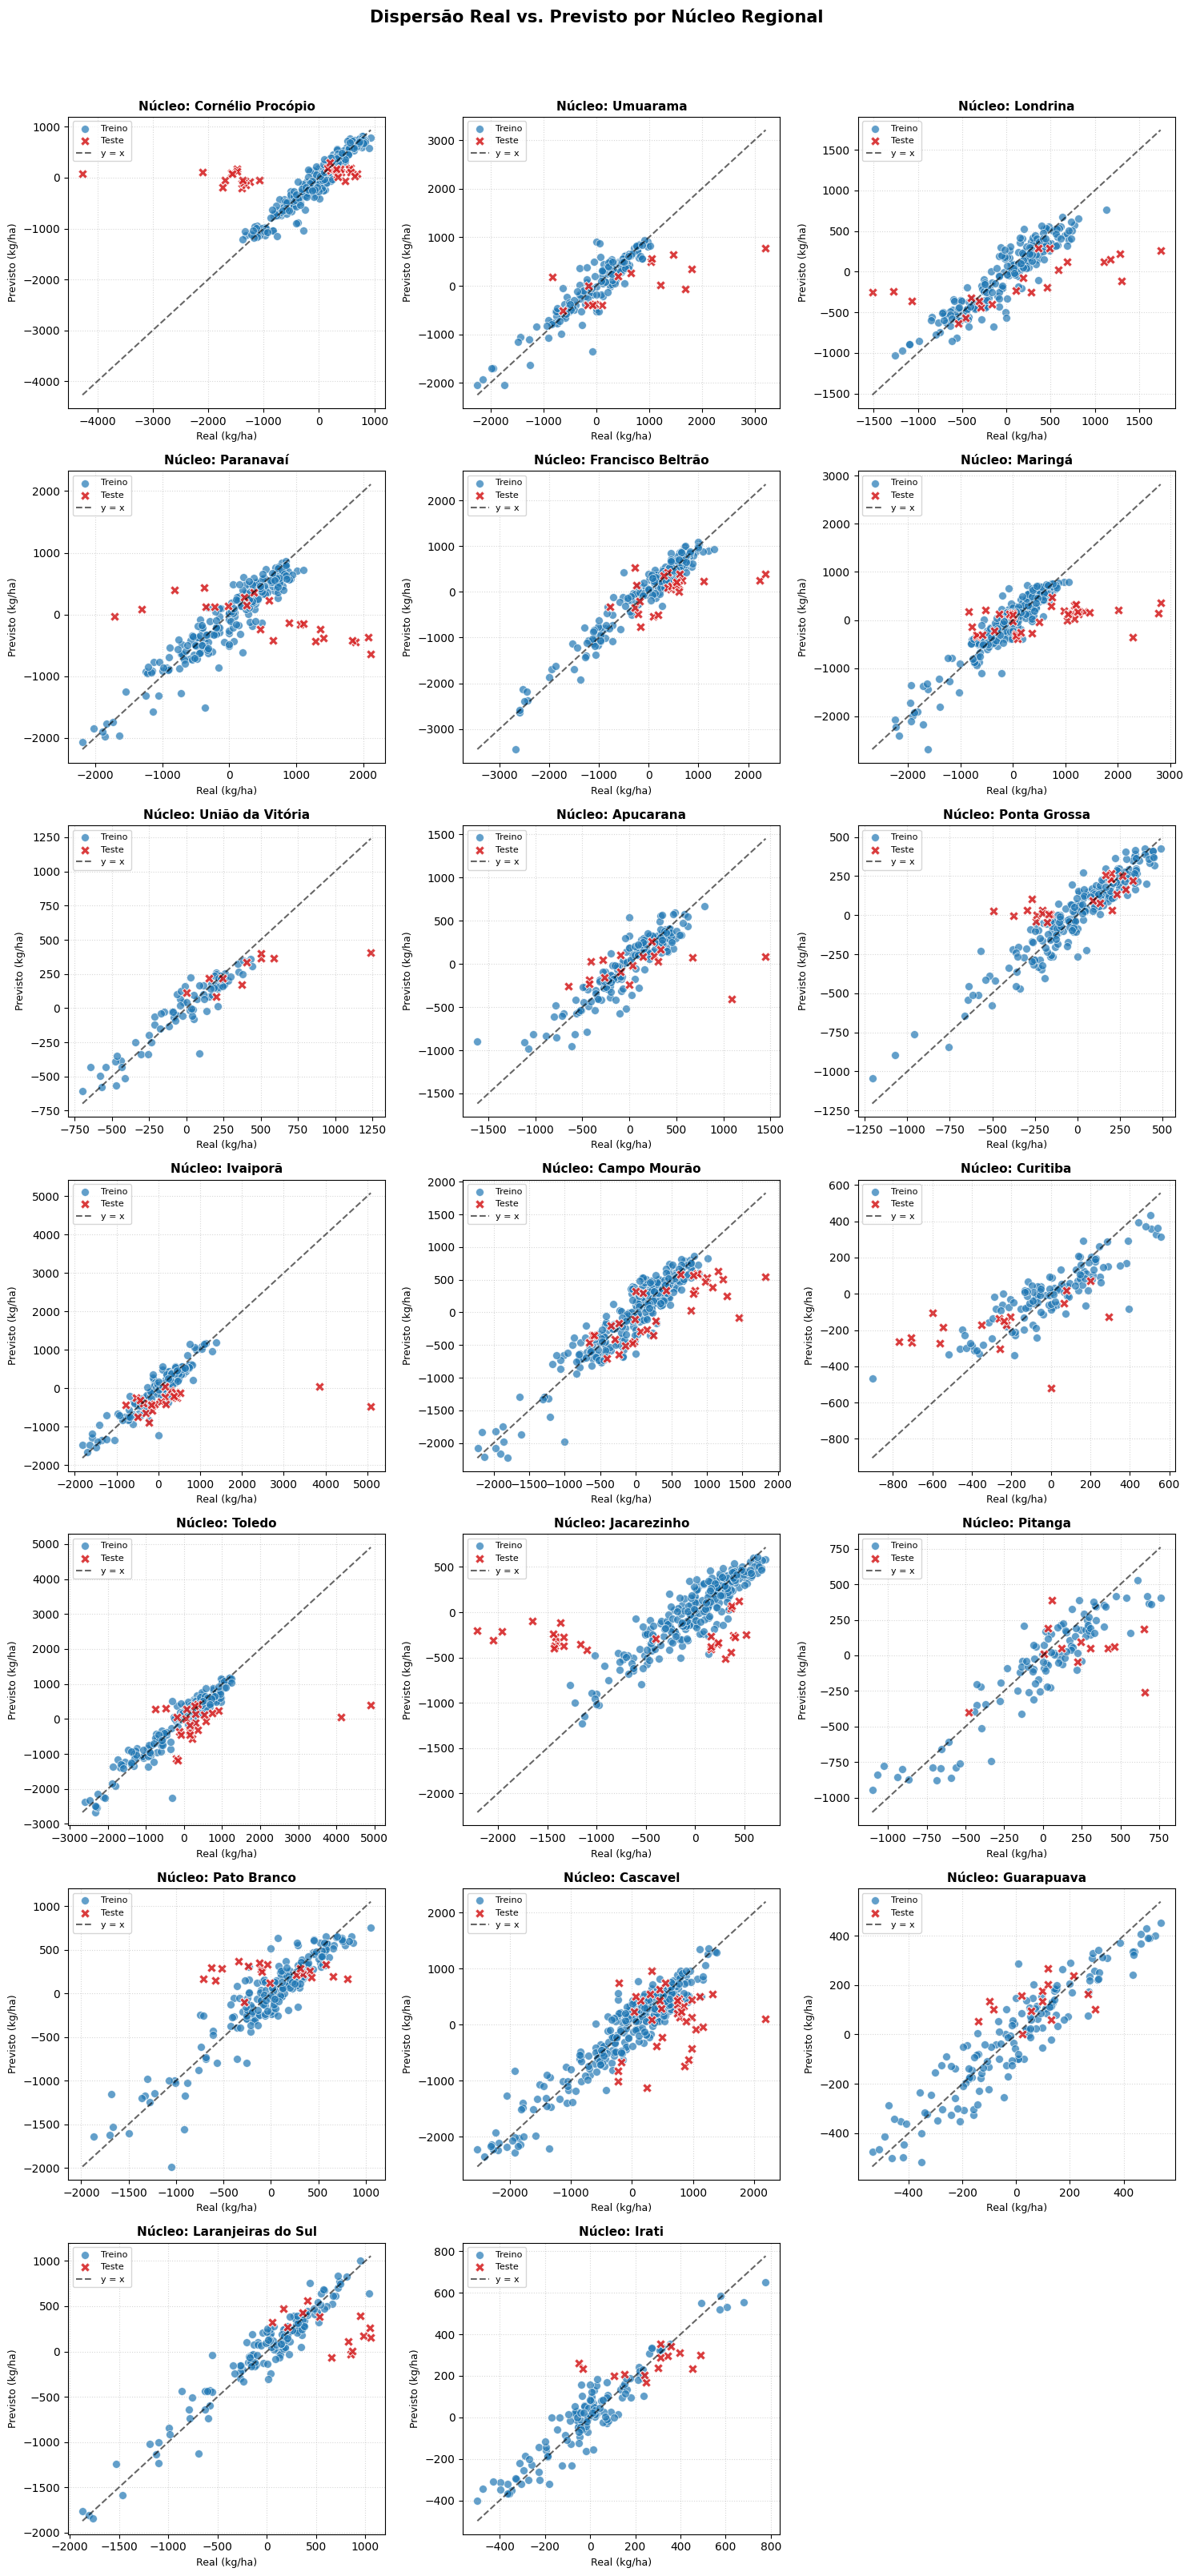

In [ ]:
# ==========================================
# CÉLULA 2: Painel de Dispersão
# ==========================================
n_nucleos = len(dados_graficos)
ncols = 3
nrows = int(np.ceil(n_nucleos / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten() if n_nucleos > 1 else [axes]

for idx, (nucleo, data) in enumerate(dados_graficos.items()):
    ax = axes[idx]

    sns.scatterplot(x=data['y_tr_real'], y=data['y_tr_pred'], color='#1f77b4', alpha=0.7, label='Treino', ax=ax, s=50)
    sns.scatterplot(x=data['y_te_real'], y=data['y_te_pred'], color='#d62728', alpha=0.9, label='Teste', ax=ax, s=70, marker='X')

    lims = [
        min(data['y_tr_real'].min(), data['y_te_real'].min(), data['y_tr_pred'].min(), data['y_te_pred'].min()),
        max(data['y_tr_real'].max(), data['y_te_real'].max(), data['y_tr_pred'].max(), data['y_te_pred'].max())
    ]
    ax.plot(lims, lims, 'k--', alpha=0.6, label='y = x')

    ax.set_title(f"Núcleo: {nucleo}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Real (kg/ha)", fontsize=9)
    ax.set_ylabel("Previsto (kg/ha)", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

# Desativar eixos extras vazios na grade
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Dispersão Real vs. Previsto por Núcleo Regional", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

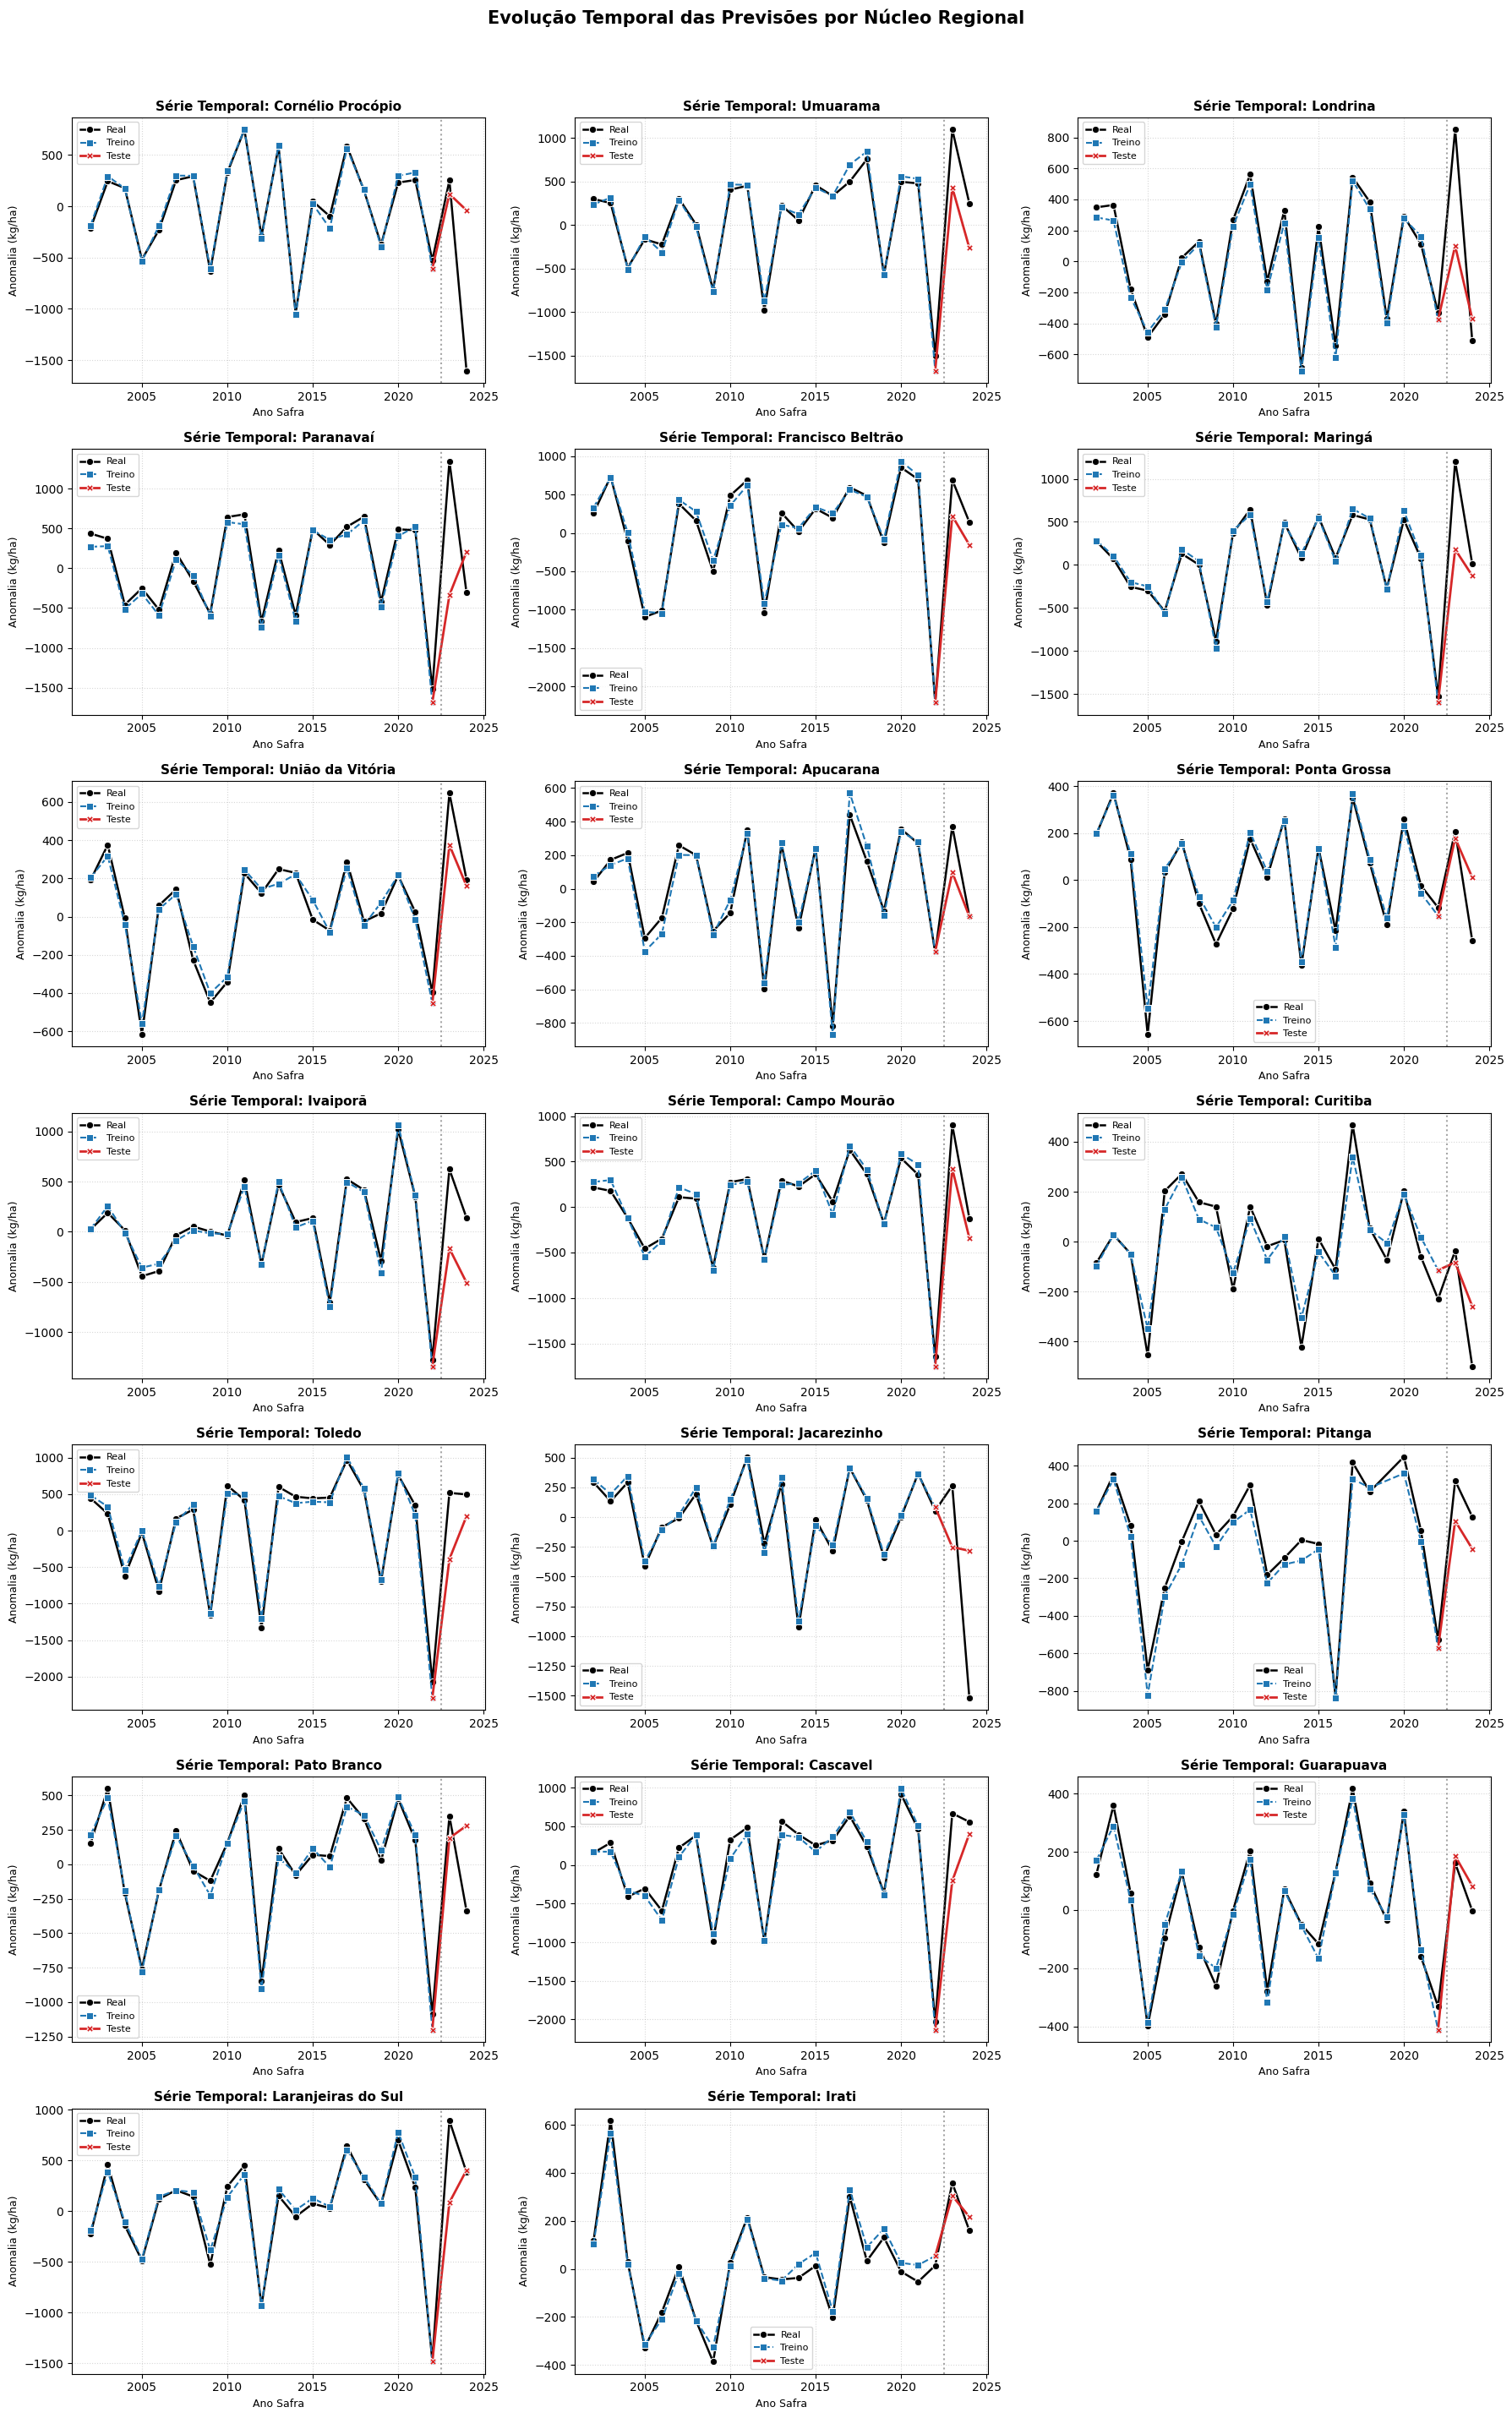

In [ ]:
# ==========================================
# CÉLULA 3: Painel de Séries Temporais
# ==========================================
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4))
axes = axes.flatten() if n_nucleos > 1 else [axes]

for idx, (nucleo, data) in enumerate(dados_graficos.items()):
    ax = axes[idx]

    df_tr = pd.DataFrame({'ano_safra': data['df_train']['ano_safra'], 'Real': data['y_tr_real'], 'Previsto': data['y_tr_pred'], 'Conjunto': 'Treino'})
    df_te = pd.DataFrame({'ano_safra': data['df_test']['ano_safra'], 'Real': data['y_te_real'], 'Previsto': data['y_te_pred'], 'Conjunto': 'Teste'})

    df_agg = pd.concat([df_tr, df_te]).groupby(['ano_safra', 'Conjunto']).mean().reset_index()

    # Conectando linha do tempo entre treino e teste
    df_tr_agg = df_agg[df_agg['Conjunto'] == 'Treino'].copy()
    df_te_agg = df_agg[df_agg['Conjunto'] == 'Teste'].copy()
    if not df_tr_agg.empty and not df_te_agg.empty:
        ponto = df_tr_agg.iloc[[-1]].copy()
        ponto['Conjunto'] = 'Teste'
        df_te_agg = pd.concat([ponto, df_te_agg])

    df_plot = pd.concat([df_tr_agg, df_te_agg])

    sns.lineplot(data=df_plot, x='ano_safra', y='Real', color='black', marker='o', ax=ax, label='Real', linewidth=1.8)
    sns.lineplot(data=df_plot[df_plot['Conjunto'] == 'Treino'], x='ano_safra', y='Previsto', color='#1f77b4', marker='s', linestyle='--', ax=ax, label='Treino')
    sns.lineplot(data=df_plot[df_plot['Conjunto'] == 'Teste'], x='ano_safra', y='Previsto', color='#d62728', marker='X', ax=ax, label='Teste', linewidth=2)

    ax.axvline(x=ANO_CORTE_TREINO + 0.5, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(f"Série Temporal: {nucleo}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Ano Safra", fontsize=9)
    ax.set_ylabel("Anomalia (kg/ha)", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=8)

for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Evolução Temporal das Previsões por Núcleo Regional", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

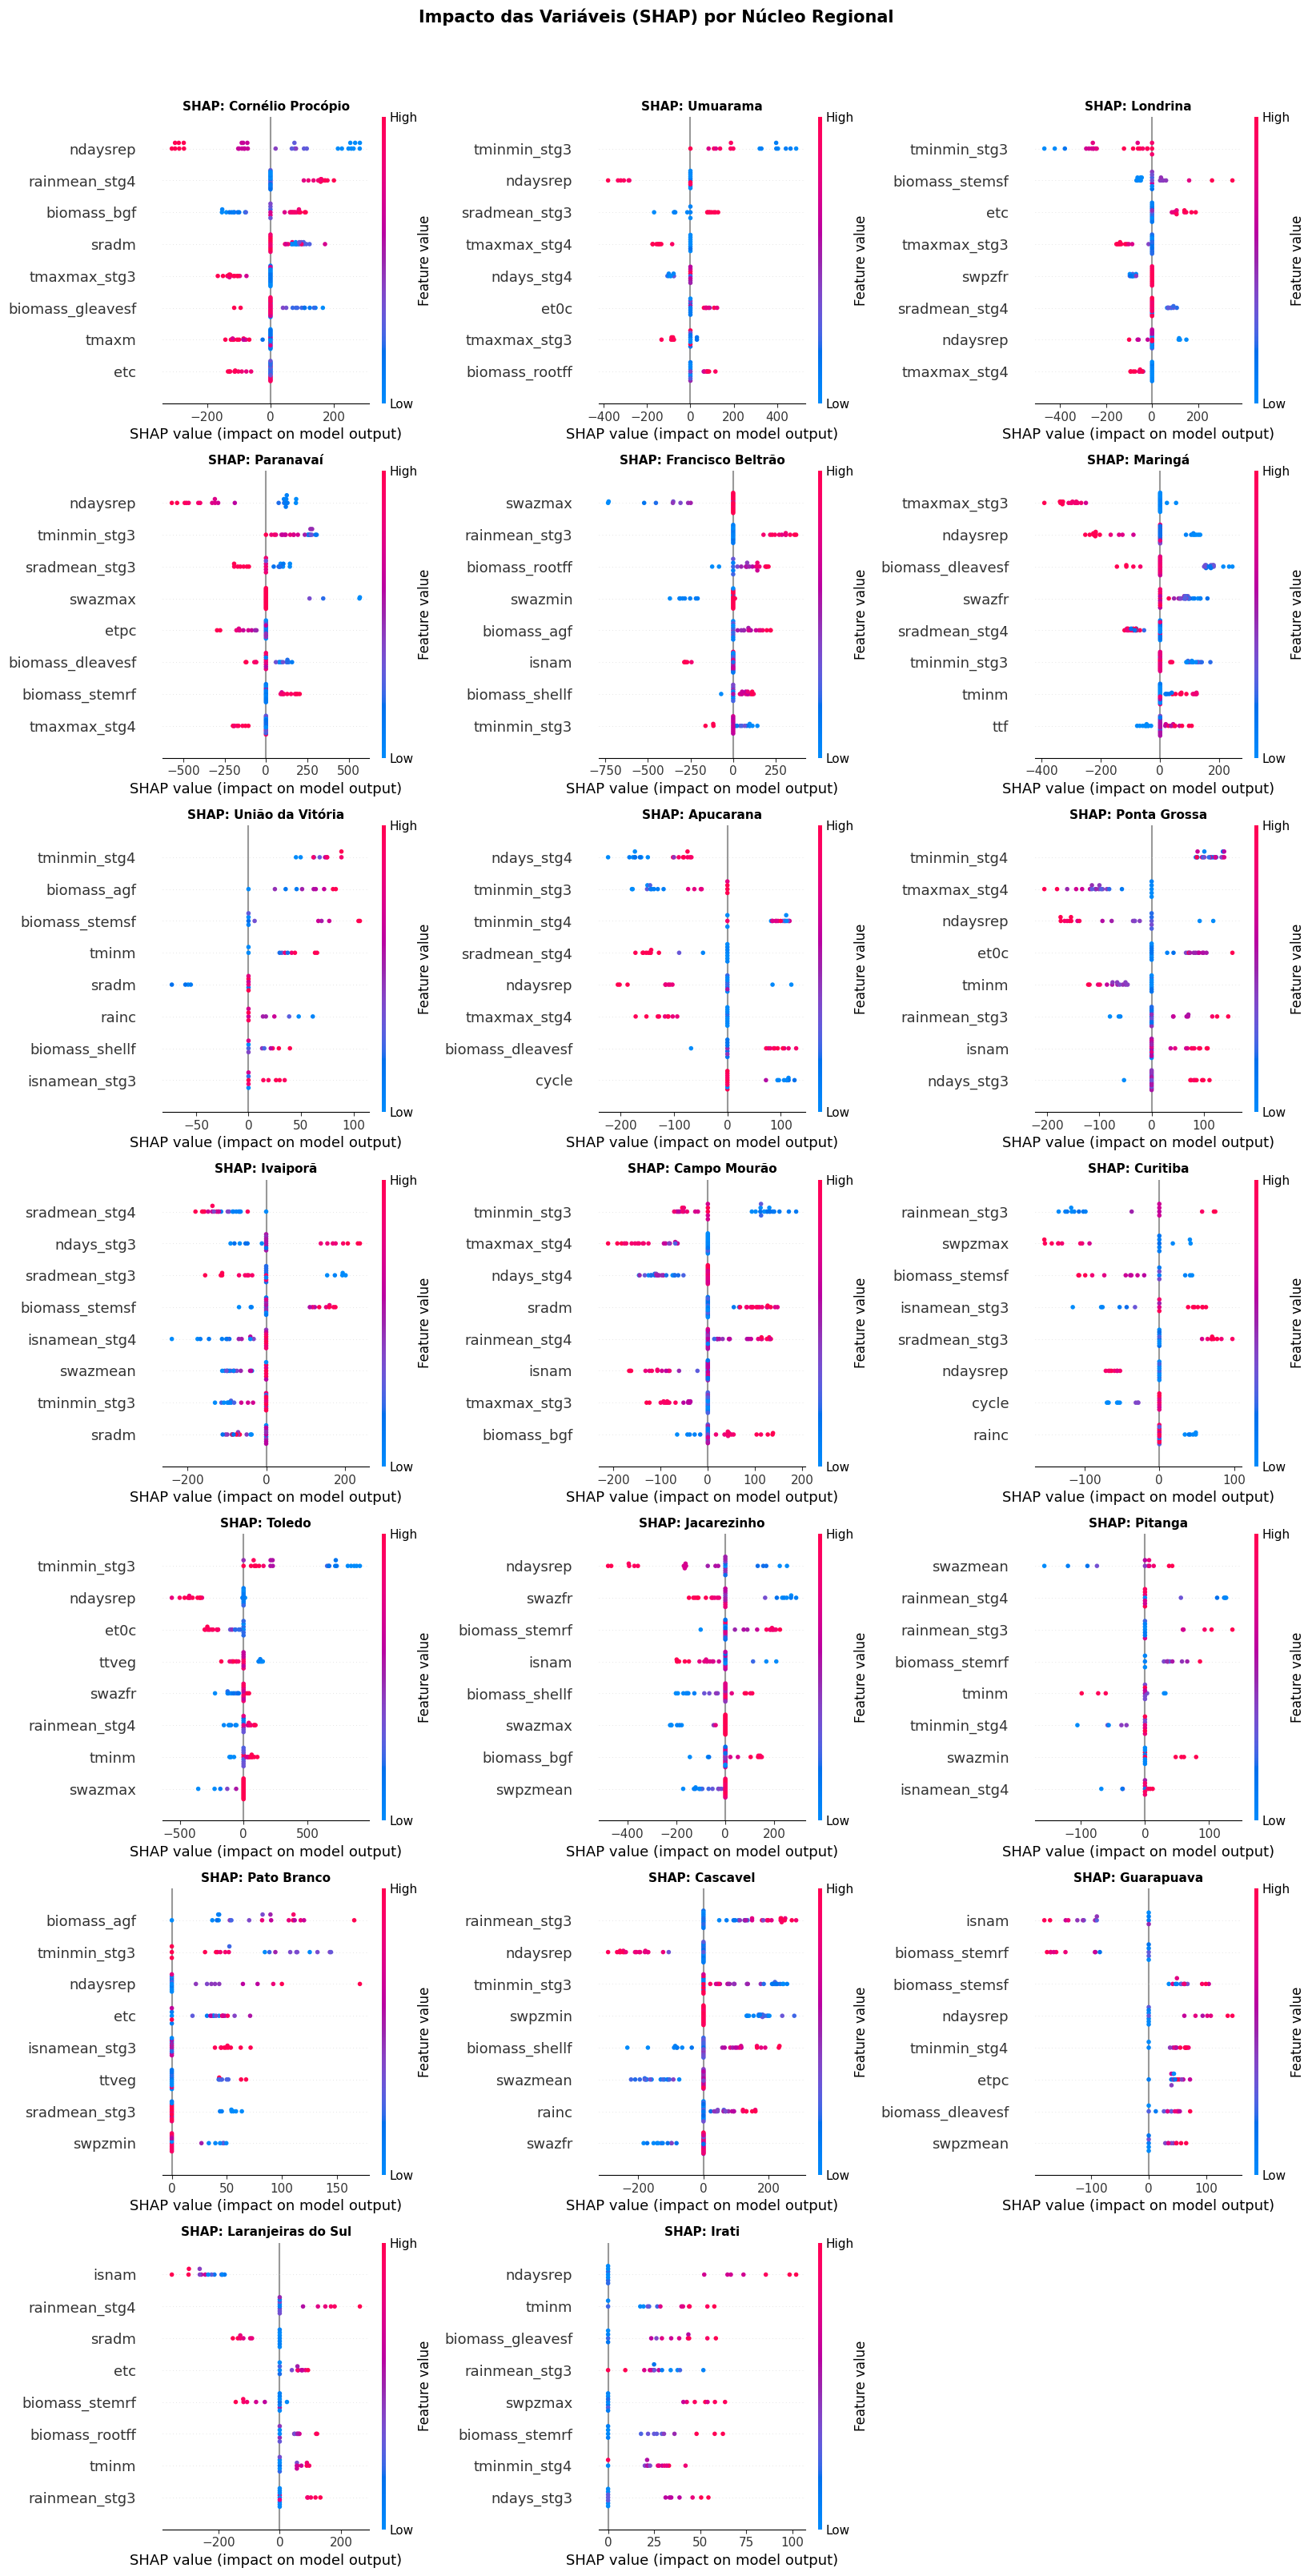

In [ ]:
# ==========================================
# CÉLULA 4: Painel do SHAP (Corrigido)
# ==========================================
fig = plt.figure(figsize=(ncols * 5.5, nrows * 4.5))

for idx, (nucleo, data) in enumerate(dados_graficos.items()):
    ax = fig.add_subplot(nrows, ncols, idx + 1)

    # Plotta o resumo do SHAP no subplot atual
    shap.summary_plot(
        data['shap_vals'],
        data['test_samples_df'],
        show=False,
        plot_size=None,
        max_display=8
    )
    plt.title(f"SHAP: {nucleo}", fontsize=11, fontweight='bold')

plt.suptitle("Impacto das Variáveis (SHAP) por Núcleo Regional", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CÉLULA 5: Tabela de Resultados e Download
# ==========================================
import pandas as pd
from google.colab import files

# Converte a lista de resultados processada na Célula 1 em DataFrame
df_resultados_finais = pd.DataFrame(resultados_lista)

print("="*85)
print("📊 RESUMO GERAL DOS RESULTADOS DE PREVISÃO POR NÚCLEO REGIONAL")
print("="*85)

# Exibe a tabela interativa no Colab
display(df_resultados_finais)

# Definição dos caminhos temporários no ambiente do Colab
caminho_csv = "/content/Resultados_Previsao_Por_Nucleo_Regional.csv"
caminho_xlsx = "/content/Resultados_Previsao_Por_Nucleo_Regional.xlsx"

# Salva a tabela nos dois formatos
df_resultados_finais.to_csv(caminho_csv, index=False, encoding='utf-8-sig')
df_resultados_finais.to_excel(caminho_xlsx, index=False)

print("\n💾 Iniciando download automático dos arquivos temporários...")
files.download(caminho_csv)
files.download(caminho_xlsx)

📊 RESUMO GERAL DOS RESULTADOS DE PREVISÃO POR NÚCLEO REGIONAL


,NUCLEO REGIONAL,R2_Treino,MAE_Treino,NRMSE_Treino,R2_Teste,MAE_Teste,NRMSE_Teste
0,Cornélio Procópio,0.9212,99.39,0.0589,-0.3128,994.79,0.2644
1,Umuarama,0.8449,177.21,0.0783,0.0674,747.19,0.2442
2,Londrina,0.8533,133.36,0.0708,0.2306,583.68,0.2280
3,Paranavaí,0.8744,178.42,0.0713,-0.9127,1164.31,0.3703
4,Francisco Beltrão,0.9309,160.16,0.0526,-0.0535,528.45,0.2310
5,Maringá,0.8872,148.50,0.0610,-0.2139,823.24,0.2879
6,União da Vitória,0.8737,73.35,0.0848,0.1894,187.62,0.2344
7,Apucarana,0.8218,118.47,0.0664,-0.0434,352.57,0.2570
8,Ponta Grossa,0.8870,75.46,0.0558,0.2445,170.78,0.2616
9,Ivaiporã,0.8658,141.21,0.0640,-0.2217,787.86,0.2547



💾 Iniciando download automático dos arquivos temporários...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>